# MaisonDeLUX — Modèle final de prédiction immobilière

## 1.1. Objectif du projet

Ce notebook unifie le travail Machine Learning du projet **MaisonDeLUX Maroc**. Le problème est une **régression** : nous voulons estimer un prix en dirhams à partir des informations réellement disponibles dans le formulaire de production.

Les métriques principales sont :

- **R²** : part de la variabilité expliquée ;
- **MAE** : erreur absolue moyenne, facile à expliquer en DH ;
- **RMSE** : pénalise davantage les très grandes erreurs.

La priorité scientifique est claire : *ma kayn la fuite de données, la test bricolé*. Le jeu de test reste séparé jusqu'à l'évaluation finale.

# 1- Importation des bibliothèques et configuration

Les chemins sont relatifs au dépôt. Le notebook fonctionne depuis la racine du projet ou depuis son propre dossier.

In [1]:
from __future__ import annotations

import hashlib
import json
import re
import time
import warnings
from datetime import date
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
from IPython.display import display
from sklearn.base import clone
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import (
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    HistGradientBoostingRegressor,
    IsolationForest,
    RandomForestRegressor,
    VotingRegressor,
)
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error,
    median_absolute_error,
    r2_score,
)
from sklearn.model_selection import GroupKFold, GroupShuffleSplit, RandomizedSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.tree import DecisionTreeRegressor

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams.update({'figure.figsize': (10, 6), 'axes.titlesize': 14, 'axes.labelsize': 11})

def find_project_root() -> Path:
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / 'data' / 'raw' / 'maisonlux_maroc_complet.csv').exists():
            return candidate
    raise FileNotFoundError('Racine MaisonDeLUX introuvable.')

PROJECT_ROOT = find_project_root()
DATA_PATH = PROJECT_ROOT / 'data' / 'raw' / 'maisonlux_maroc_complet.csv'
ARTIFACTS_DIR = PROJECT_ROOT / 'ml' / 'artifacts'

print('Racine :', PROJECT_ROOT)
print('Versions :', {'pandas': pd.__version__, 'numpy': np.__version__, 'scikit-learn': sklearn.__version__, 'joblib': joblib.__version__})

Racine : C:\Users\ouaha\OneDrive\Desktop\MaisonDeLUX
Versions : {'pandas': '2.2.3', 'numpy': '2.4.4', 'scikit-learn': '1.8.0', 'joblib': '1.5.3'}


# 2- Chargement et compréhension des données

Le fichier brut provient du scraping Mubawab. Chaque ligne est une annonce sous forme de texte : titre, prix, localisation et détails.

In [2]:
df_raw = pd.read_csv(DATA_PATH)
print(f'Dimensions brutes : {df_raw.shape[0]:,} lignes × {df_raw.shape[1]} colonnes')
display(df_raw.head(10))

audit_brut = pd.DataFrame({
    'Type': df_raw.dtypes.astype(str),
    'Valeurs_manquantes': df_raw.isna().sum(),
    'Valeurs_uniques': df_raw.nunique(dropna=False),
})
display(audit_brut)
print('Doublons exacts :', int(df_raw.duplicated().sum()))
print('Taille maximale d’un groupe identique :', int(df_raw.groupby(list(df_raw.columns), dropna=False).size().max()))

Dimensions brutes : 16,858 lignes × 4 colonnes


,Titre,Prix,Localisation,Details
0,Studios Neufs A Vendre Le Vrai Centre de Gueliz,730 000 DH,"Guéliz, Marrakech",42 m² 2 Pièces 1 Ch. 1 Salle de bain
1,Appartement Rez de jardin avec 300m2 Jardin Privé,980 000 DH,"Route de Ouarzazate, Marrakech",116 m² 3 Pièces 2 Chambres 2 Salles de bains
2,Appartement centre ville investissement locatif,1 290 000 EUR,"Guéliz, Marrakech",61 m² 2 Pièces 1 Ch. 1 Salle de bain
3,Green Lotus,Projet · 10 biens immobiliers,"Sidi Maarouf, Casablanca",Haut standing En cours de construction Livrais...
4,Appartement à vendre à Les Hôpitaux. 1 chambre...,1 242 000 DH,"Les Hôpitaux, Casablanca",47 m² 1 Pièce 1 Ch. 1 Salle de bain
5,Appartement à l'achat à Californie. 2 chambres...,1 712 500 DH,"Californie, Casablanca",100 m² 3 Pièces 2 Chambres 2 Salles de bains
6,Vente d'un bel appartement à Belvédère. 2 bell...,950 000 DH,"Belvédère, Casablanca",82 m² 3 Pièces 2 Chambres 1 Salle de bain
7,Appartement neuf résidence azzahra 2 said hajji,370 000 DH,"Abouab Sala, Salé",53 m² 3 Pièces 2 Chambres 1 Salle de bain
8,Residence Montarista,À partir de 3 800 000 DH,"Route de Tahanaout, Marrakech",Haut standing En cours de construction Livrais...
9,Superbe appartement à casablanca: 181 m² 2 pp,2 800 000 DH,"Maârif Extension, Casablanca",181 m² 3 Pièces 3 Chambres 2 Salles de bains


,Type,Valeurs_manquantes,Valeurs_uniques
Titre,object,0,14791
Prix,object,0,1838
Localisation,object,0,906
Details,object,0,5179


Doublons exacts : 1006
Taille maximale d’un groupe identique : 171


# 3- Audit qualité : extraction des variables utiles

Les transformations suivantes ne modifient pas le CSV brut. Elles permettent d'auditer les valeurs et de construire une cohorte cohérente avec le formulaire de production.

In [3]:
def parse_price(value: object) -> float:
    if pd.isna(value):
        return np.nan
    text = str(value).lower()
    if 'consulter' in text or 'projet' in text:
        return np.nan
    digits = re.sub(r'[^0-9]', '', text.replace('à partir de', ''))
    if not digits:
        return np.nan
    price = float(digits)
    return price * 10.8 if 'eur' in text else price

def split_location(series: pd.Series) -> tuple[pd.Series, pd.Series]:
    parts = series.astype('string').str.split(',', n=1, expand=True)
    first = parts[0].fillna('').str.strip()
    if parts.shape[1] == 1:
        return pd.Series('Non renseigné', index=series.index), first
    second = parts[1].fillna('').str.strip()
    has_comma = second.ne('')
    return first.where(has_comma, 'Non renseigné'), second.where(has_comma, first)

def normalize_text(series: pd.Series, fallback: str = 'Non renseigné') -> pd.Series:
    clean = series.astype('string').fillna('').str.replace(r'\s+', ' ', regex=True).str.strip()
    return clean.mask(clean.eq(''), fallback)

def extract_common(raw: pd.DataFrame) -> pd.DataFrame:
    df = raw.copy()
    df['Prix_num'] = df['Prix'].map(parse_price)
    df['Quartier'], df['Ville'] = split_location(df['Localisation'])
    df['Quartier'] = normalize_text(df['Quartier'])
    df['Ville'] = normalize_text(df['Ville'])
    details = df['Details'].astype('string')
    df['Surface_m2'] = pd.to_numeric(details.str.extract(r'(\d+)\s*m²', expand=False), errors='coerce')
    df['Pieces'] = pd.to_numeric(details.str.extract(r'(\d+)\s*Pièce', expand=False), errors='coerce')
    df['Chambres'] = pd.to_numeric(details.str.extract(r'(\d+)\s*Ch', expand=False), errors='coerce')
    df['Salles_Bain'] = pd.to_numeric(details.str.extract(r'(\d+)\s*Salle', expand=False), errors='coerce')
    df['Is_Haut_Standing'] = details.str.contains('Haut standing', case=False, na=False).astype(int)
    df['En_Construction'] = details.str.contains('En cours de construction', case=False, na=False).astype(int)
    title = df['Titre'].astype('string').fillna('').str.casefold()
    combined_text = title + ' ' + details.fillna('').str.casefold()
    df['Is_Haut_Standing'] = combined_text.str.contains('haut standing', regex=False).astype(int)
    df['En_Construction'] = combined_text.str.contains('en cours de construction', regex=False).astype(int)
    conditions = [
        title.str.contains('studio', regex=False), title.str.contains('duplex', regex=False),
        title.str.contains('villa', regex=False), title.str.contains('maison', regex=False),
        title.str.contains('appartement', regex=False),
    ]
    df['Type_Bien'] = np.select(conditions, ['studio', 'duplex', 'villa', 'maison', 'appartement'], default='inconnu')
    return df

df_audit = extract_common(df_raw.drop_duplicates())
df_audit['Prix_m2_audit'] = df_audit['Prix_num'] / df_audit['Surface_m2']

audit_numerique = df_audit[['Prix_num', 'Surface_m2', 'Pieces', 'Chambres', 'Salles_Bain', 'Prix_m2_audit']].describe(
    percentiles=[.001, .01, .05, .5, .95, .99, .999]
).T
display(audit_numerique)

quality_counts = pd.Series({
    'Lignes brutes': len(df_raw),
    'Doublons exacts': df_raw.duplicated().sum(),
    'Prix non exploitables': df_audit['Prix_num'].isna().sum(),
    'Surface manquante': df_audit['Surface_m2'].isna().sum(),
    'Surface <= 0': df_audit['Surface_m2'].le(0).sum(),
    'Surface > 1 000 m²': df_audit['Surface_m2'].gt(1000).sum(),
    'Pièces > 15': df_audit['Pieces'].gt(15).sum(),
    'Chambres > pièces': (df_audit['Chambres'] > df_audit['Pieces']).sum(),
    'Type non reconnu par l’API': df_audit['Type_Bien'].eq('inconnu').sum(),
})
display(quality_counts.to_frame('Nombre'))

,count,mean,std,min,0.1%,1%,5%,50%,95%,99%,99.9%,max
Prix_num,"14,683.000","2,534,671.206","17,246,865.260","6,400.000","6,800.000","9,900.000","280,000.000","1,300,000.000","4,500,000.000","10,000,000.000","236,590,000.000","950,000,000.000"
Surface_m2,"15,755.000",123.189,477.886,11.000,30.000,41.000,50.000,97.000,229.000,377.000,"2,049.200","50,000.000"
Pieces,"14,272.000",3.424,1.901,1.000,1.000,1.000,1.000,3.000,6.000,9.000,16.729,41.000
Chambres,"15,668.000",2.403,0.992,1.000,1.000,1.000,1.000,2.000,4.000,5.000,10.000,30.000
Salles_Bain,"15,584.000",1.781,0.832,1.000,1.000,1.000,1.000,2.000,3.000,4.000,8.000,18.000
Prix_m2_audit,"14,599.000","22,729.106","205,315.893",3.000,50.000,100.000,"4,000.000","13,166.667","28,846.154","66,686.717","1,713,115.460","18,518,521.333"


,Nombre
Lignes brutes,16858
Doublons exacts,1006
Prix non exploitables,1169
Surface manquante,97
Surface <= 0,0
Surface > 1 000 m²,31
Pièces > 15,17
Chambres > pièces,1776
Type non reconnu par l’API,1889


# 4- Analyse exploratoire des données (EDA)

Les distributions immobilières sont fortement asymétriques. On visualise donc les valeurs brutes et leur logarithme sans supprimer automatiquement les extrêmes.

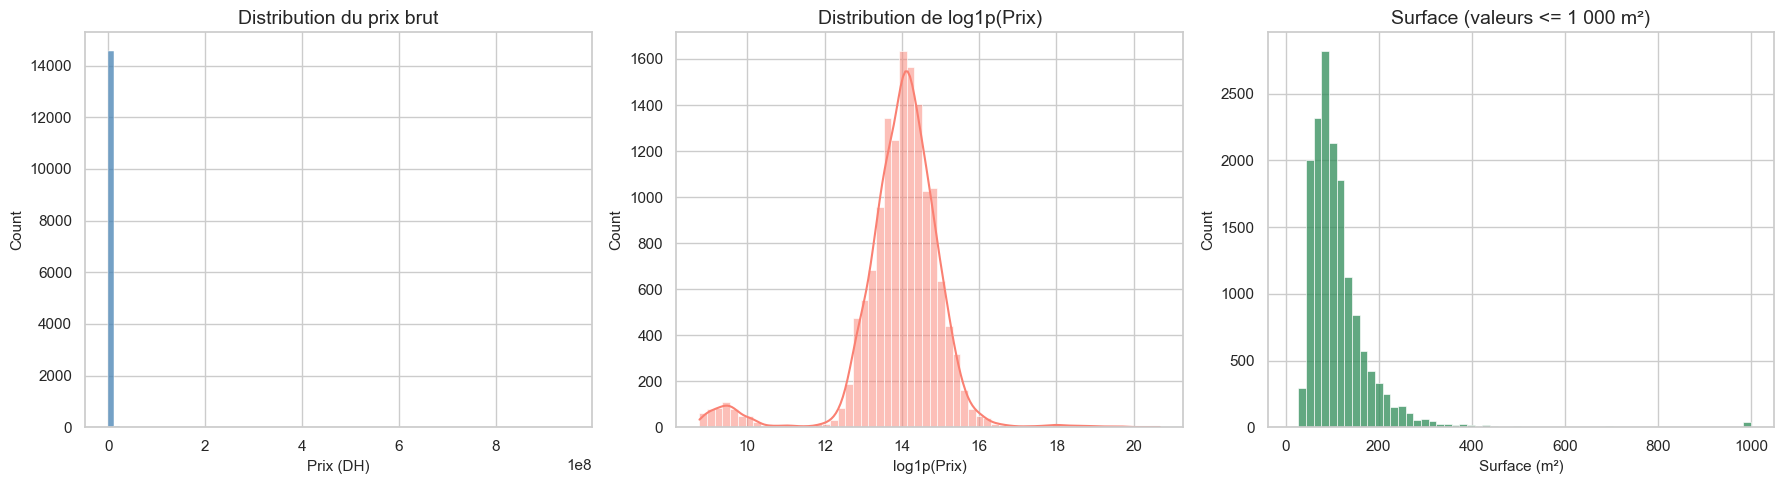

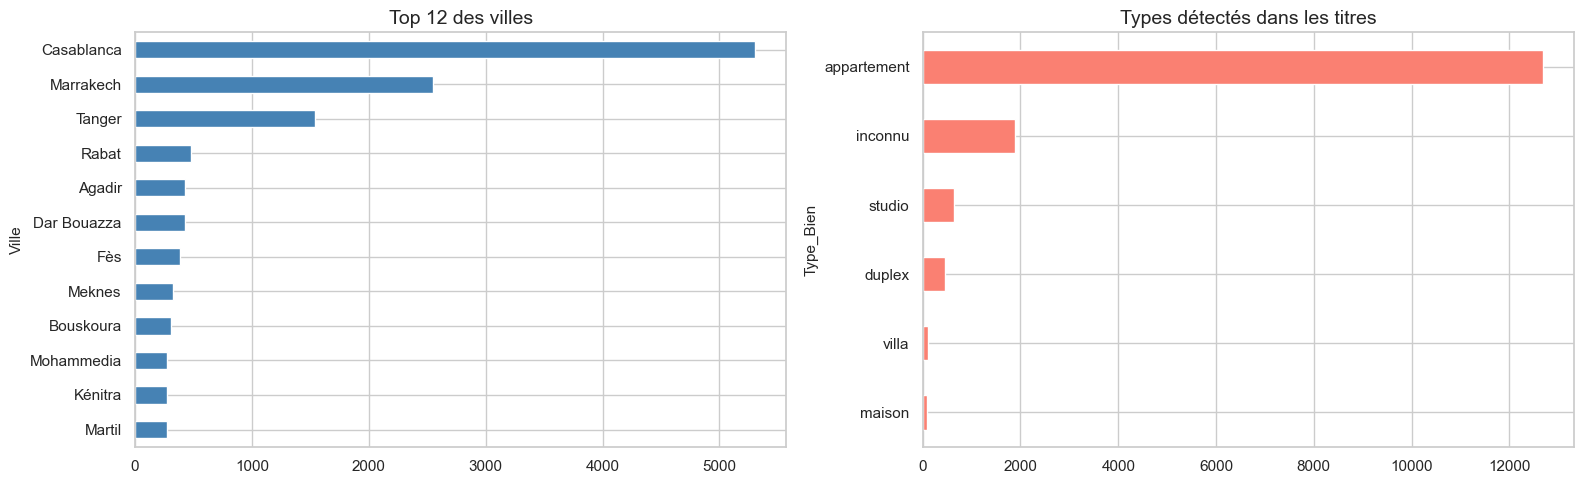

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(df_audit['Prix_num'].dropna(), bins=80, ax=axes[0], color='steelblue')
axes[0].set_title('Distribution du prix brut')
axes[0].set_xlabel('Prix (DH)')
sns.histplot(np.log1p(df_audit['Prix_num'].dropna()), bins=60, kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Distribution de log1p(Prix)')
axes[1].set_xlabel('log1p(Prix)')
sns.histplot(df_audit['Surface_m2'].dropna().clip(upper=1000), bins=60, ax=axes[2], color='seagreen')
axes[2].set_title('Surface (valeurs <= 1 000 m²)')
axes[2].set_xlabel('Surface (m²)')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
df_audit['Ville'].value_counts().head(12).sort_values().plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Top 12 des villes')
df_audit['Type_Bien'].value_counts().sort_values().plot(kind='barh', ax=axes[1], color='salmon')
axes[1].set_title('Types détectés dans les titres')
plt.tight_layout()
plt.show()

# 5- Audit des fuites de données de l'ancien pipeline

L'ancien notebook présente plusieurs sources d'optimisme artificiel :

1. `IsolationForest` est ajusté sur **tout le dataset** avec `Prix` avant le split ;
2. `KNNImputer` utilise également `Prix` avant le split ;
3. la fréquence des quartiers est calculée sur toutes les lignes ;
4. les catégories de ville sont créées avant le split ;
5. les hyperparamètres sont optimisés sans jeu de validation séparé ;
6. surtout, le jeu de test est filtré avec son vrai `Prix_par_m2` avant le calcul des métriques.

Le prix par m² n'est heureusement pas utilisé directement comme feature, mais son utilisation pour retirer des lignes du test rend l'évaluation non représentative. Les artefacts et `metrics.json` montrent aussi une dérive : le modèle sauvegardé ne reproduit pas les chiffres enregistrés.

# 6- Reproduction du modèle de production actuel

Cette cellule reproduit la préparation historique afin d'évaluer **le fichier `model.pkl` réellement déployé** sur le sous-ensemble historique. Elle sert uniquement de diagnostic ; ce pipeline n'est pas réutilisé pour le modèle final.

In [5]:
def regression_metrics(name: str, y_true, prediction) -> dict:
    return {
        'model': name,
        'r2': float(r2_score(y_true, prediction)),
        'mae': float(mean_absolute_error(y_true, prediction)),
        'rmse': float(mean_squared_error(y_true, prediction) ** 0.5),
        'median_ae': float(median_absolute_error(y_true, prediction)),
        'mape_percent': float(mean_absolute_percentage_error(y_true, prediction) * 100),
    }

def reproduce_current_artifact(raw: pd.DataFrame) -> dict:
    df = raw.drop_duplicates().copy()
    title = df['Titre'].astype('string').fillna('').str.upper()
    for column, pattern in {
        'type_appartement': 'APPARTEMENT', 'type_studio': 'STUDIO', 'type_maison': 'MAISON',
        'type_villa': 'VILLA', 'type_duplex': 'DUPLEX',
    }.items():
        df[column] = title.str.contains(pattern, regex=True).astype(int)
    df['Prix'] = df['Prix'].map(parse_price)
    df = df.dropna(subset=['Prix'])
    df['Quartier'], df['Ville'] = split_location(df['Localisation'])
    details = df['Details'].astype('string')
    df['Surface_m2'] = pd.to_numeric(details.str.extract(r'(\d+)\s*m²', expand=False), errors='coerce')
    df['Pieces'] = pd.to_numeric(details.str.extract(r'(\d+)\s*Pièce', expand=False), errors='coerce')
    df['Chambres'] = pd.to_numeric(details.str.extract(r'(\d+)\s*Ch', expand=False), errors='coerce')
    df['Salles_Bain'] = pd.to_numeric(details.str.extract(r'(\d+)\s*Salle', expand=False), errors='coerce')
    df['Is_Haut_Standing'] = details.str.contains('Haut standing', case=False, na=False).astype(int)
    df['En_Construction'] = details.str.contains('En cours de construction', case=False, na=False).astype(int)
    for column in ['Surface_m2', 'Pieces', 'Chambres', 'Salles_Bain']:
        q1, q3 = df[column].quantile([.25, .75]); iqr = q3 - q1
        df = df[df[column].between(q1 - 1.5 * iqr, q3 + 1.5 * iqr)]
    iso_cols = ['Prix', 'Surface_m2', 'Pieces', 'Chambres', 'Salles_Bain']
    temp = SimpleImputer(strategy='median').fit_transform(df[iso_cols])
    df = df.loc[IsolationForest(contamination=.05, random_state=42).fit_predict(temp) == 1].copy()
    knn_cols = ['Prix', 'Surface_m2', 'Pieces', 'Chambres', 'Salles_Bain', 'type_appartement',
                'type_studio', 'type_maison', 'type_villa', 'type_duplex', 'Is_Haut_Standing', 'En_Construction']
    df[knn_cols] = KNNImputer(n_neighbors=5).fit_transform(df[knn_cols])
    model_df = df.drop(columns=['Titre', 'Localisation'], errors='ignore')
    freq = model_df['Quartier'].value_counts(normalize=True)
    model_df['Quartier_freq'] = model_df['Quartier'].map(freq)
    model_df = pd.get_dummies(model_df.drop(columns=['Quartier']), columns=['Ville'], prefix='ville', drop_first=True)
    model_df['Prix_par_m2'] = model_df['Prix'] / model_df['Surface_m2']
    X = model_df.drop(columns=['Prix', 'Prix_par_m2']); y = model_df['Prix']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2, random_state=42)
    numeric = ['Surface_m2', 'Pieces', 'Chambres', 'Salles_Bain', 'Quartier_freq']
    scaler = StandardScaler(); X_train = X_train.copy(); X_test = X_test.copy()
    X_train[numeric] = scaler.fit_transform(X_train[numeric]); X_test[numeric] = scaler.transform(X_test[numeric])
    X_train['Surface_x_Quartier'] = X_train['Surface_m2'] * X_train['Quartier_freq']
    X_test['Surface_x_Quartier'] = X_test['Surface_m2'] * X_test['Quartier_freq']
    ppm_train = model_df.loc[X_train.index, 'Prix_par_m2']; low, high = ppm_train.quantile([.01, .99])
    train_mask = ppm_train.between(low, high)
    test_mask = model_df.loc[X_test.index, 'Prix_par_m2'].between(low, high)
    X_train, y_train = X_train.loc[train_mask], y_train.loc[train_mask]
    X_test, y_test = X_test.loc[test_mask], y_test.loc[test_mask]
    columns = joblib.load(ARTIFACTS_DIR / 'feature_columns.pkl')
    model = joblib.load(ARTIFACTS_DIR / 'model.pkl')
    X_train = X_train.reindex(columns=columns, fill_value=0)
    X_test = X_test.reindex(columns=columns, fill_value=0)
    return {
        'n_after_isolation_forest': len(model_df), 'n_train': len(y_train), 'n_test': len(y_test),
        'train': regression_metrics('Current artifact - train', y_train, model.predict(X_train)),
        'test': regression_metrics('Current artifact - filtered test', y_test, model.predict(X_test)),
        'ppm2_thresholds': [float(low), float(high)],
    }

current_baseline = reproduce_current_artifact(df_raw)
display(pd.DataFrame([current_baseline['train'], current_baseline['test']]).set_index('model'))
print({k: v for k, v in current_baseline.items() if k not in ['train', 'test']})

,r2,mae,rmse,median_ae,mape_percent
model,,,,,
Current artifact - train,0.618,"400,734.284","563,307.951","289,320.096",329.594
Current artifact - filtered test,0.554,"423,485.188","603,468.995","295,572.129",350.298


{'n_after_isolation_forest': 11254, 'n_train': 8821, 'n_test': 2211, 'ppm2_thresholds': [100.82708821233412, 38569.23076923072]}


# 7- Définition transparente de la cohorte de modélisation

Le CSV brut reste intact. La cohorte finale correspond au périmètre du formulaire : biens résidentiels reconnus, surface entre 15 et 1 000 m², variables de pièces dans les limites du formulaire et annonces de vente.

Les étiquettes avec moins de **1 000 DH/m²** ou plus de **150 000 DH/m²** sont isolées comme erreurs probables de location, centimes ou saisie. Ce choix métier est fixé avant le split et toutes les exclusions sont comptées. Les biens de luxe ne sont pas masqués : ceux restant dans la cohorte sont analysés par segment et leurs erreurs sont présentées.

In [6]:
def prepare_modeling_cohort(raw: pd.DataFrame) -> tuple[pd.DataFrame, dict]:
    report = {'raw_rows': int(len(raw))}
    df = raw.drop_duplicates().copy()
    report['exact_duplicates_removed'] = int(len(raw) - len(df))
    df = extract_common(df)
    report['unlabeled_rows'] = int(df['Prix_num'].isna().sum())
    df = df[df['Prix_num'].notna()].copy()
    report['unknown_type_rows'] = int(df['Type_Bien'].eq('inconnu').sum())
    df = df[df['Type_Bien'].ne('inconnu')].copy()
    valid_inputs = (
        df['Surface_m2'].between(15, 1000)
        & (df['Pieces'].isna() | df['Pieces'].between(1, 15))
        & (df['Chambres'].isna() | df['Chambres'].between(0, 10))
        & (df['Salles_Bain'].isna() | df['Salles_Bain'].between(0, 10))
    )
    report['invalid_input_scope_rows'] = int((~valid_inputs).sum())
    df = df[valid_inputs].copy()
    rental_pattern = r'\b(?:louer|location|à louer|a louer|en location|locations)\b'
    rental = df['Titre'].astype('string').str.casefold().str.contains(rental_pattern, regex=True, na=False)
    report['explicit_rental_rows'] = int(rental.sum())
    df = df[~rental].copy()
    df['Prix_m2_audit'] = df['Prix_num'] / df['Surface_m2']
    plausible_label = df['Prix_m2_audit'].between(1_000, 150_000)
    report['implausible_price_per_m2_rows'] = int((~plausible_label).sum())
    df = df[plausible_label].copy()
    signature = (
        normalize_text(df['Titre']).str.casefold() + '|' +
        normalize_text(df['Localisation']).str.casefold() + '|' +
        normalize_text(df['Details']).str.casefold()
    )
    df['Listing_Group'] = pd.util.hash_pandas_object(signature, index=False).astype('uint64').astype(str)
    report.update({
        'modeling_rows': int(len(df)), 'cities': int(df['Ville'].nunique()),
        'quartiers': int(df['Quartier'].nunique()), 'listing_groups': int(df['Listing_Group'].nunique()),
        'rows_in_repeated_groups': int(df['Listing_Group'].duplicated(keep=False).sum()),
    })
    return df, report

df_model, cohort_report = prepare_modeling_cohort(df_raw)
display(pd.Series(cohort_report, name='Nombre').to_frame())
display(df_model[['Prix_num', 'Surface_m2', 'Pieces', 'Chambres', 'Salles_Bain', 'Prix_m2_audit']].describe().T)

,Nombre
raw_rows,16858
exact_duplicates_removed,1006
unlabeled_rows,1169
unknown_type_rows,1762
invalid_input_scope_rows,23
explicit_rental_rows,109
implausible_price_per_m2_rows,472
modeling_rows,12267
cities,150
quartiers,736


,count,mean,std,min,25%,50%,75%,max
Prix_num,"12,267.000","1,710,641.424","1,962,939.888","60,000.000","800,000.000","1,300,000.000","2,100,000.000","150,000,000.000"
Surface_m2,"12,267.000",112.791,65.011,23.000,73.000,98.000,133.000,"1,000.000"
Pieces,"10,873.000",3.455,1.717,1.000,2.000,3.000,4.000,15.000
Chambres,"12,151.000",2.385,0.819,1.000,2.000,2.000,3.000,10.000
Salles_Bain,"12,088.000",1.782,0.783,1.000,1.000,2.000,2.000,9.000
Prix_m2_audit,"12,267.000","14,952.958","9,243.371","1,000.000","9,313.725","13,333.333","18,500.000","150,000.000"


# 8- Séparation Train / Validation / Test sans doublons croisés

- **Train (70%)** : apprentissage et cross-validation ;
- **Validation (15%)** : choix du modèle et du poids de l'ensemble ;
- **Test (15%)** : ouvert une seule fois après le choix final.

`GroupShuffleSplit` garde les signatures de listings similaires dans un seul ensemble.

In [7]:
split_test = GroupShuffleSplit(n_splits=1, test_size=.15, random_state=42)
train_val_idx, test_idx = next(split_test.split(df_model, groups=df_model['Listing_Group']))
df_train_val = df_model.iloc[train_val_idx]
df_test = df_model.iloc[test_idx]
split_val = GroupShuffleSplit(n_splits=1, test_size=.1764705882, random_state=43)
train_idx, val_idx = next(split_val.split(df_train_val, groups=df_train_val['Listing_Group']))
df_train = df_train_val.iloc[train_idx]
df_validation = df_train_val.iloc[val_idx]

split_report = pd.Series({
    'Train': len(df_train), 'Validation': len(df_validation), 'Test': len(df_test),
    'Groupes train ∩ validation': len(set(df_train.Listing_Group) & set(df_validation.Listing_Group)),
    'Groupes train ∩ test': len(set(df_train.Listing_Group) & set(df_test.Listing_Group)),
    'Groupes validation ∩ test': len(set(df_validation.Listing_Group) & set(df_test.Listing_Group)),
})
display(split_report.to_frame('Nombre'))

,Nombre
Train,8585
Validation,1838
Test,1844
Groupes train ∩ validation,0
Groupes train ∩ test,0
Groupes validation ∩ test,0


# 9- Preprocessing et feature engineering

Tout objet qui apprend une statistique (`SimpleImputer`, encodeur, scaler) est placé dans une `Pipeline` et ajusté uniquement sur le train.

Deux variantes sont testées :

- variables de production simples ;
- ratios surface/pièces, densité des salles de bain, interactions et ville × type.

Aucune feature n'utilise le prix.

In [8]:
BASE_NUMERIC = ['Surface_m2', 'Pieces', 'Chambres', 'Salles_Bain', 'Is_Haut_Standing', 'En_Construction']
BASE_CATEGORICAL = ['Type_Bien', 'Ville', 'Quartier']

def make_features(df: pd.DataFrame, engineered: bool = False):
    X = df[BASE_NUMERIC + BASE_CATEGORICAL].copy()
    numeric = BASE_NUMERIC.copy(); categorical = BASE_CATEGORICAL.copy()
    if engineered:
        X['Surface_par_Piece'] = X['Surface_m2'] / X['Pieces'].clip(lower=1)
        X['Surface_par_Chambre'] = X['Surface_m2'] / X['Chambres'].clip(lower=1)
        X['Ratio_Chambres_Pieces'] = X['Chambres'] / X['Pieces'].clip(lower=1)
        X['Densite_Salles_Bain'] = X['Salles_Bain'] / X['Surface_m2'].clip(lower=1)
        X['Ecart_Pieces_Chambres'] = X['Pieces'] - X['Chambres']
        X['Chambres_Sup_Pieces'] = (X['Chambres'] > X['Pieces']).astype(float)
        X['Surface_Haut_Standing'] = X['Surface_m2'] * X['Is_Haut_Standing']
        X['Surface_Construction'] = X['Surface_m2'] * X['En_Construction']
        X['Ville_Type'] = X['Ville'].astype('string') + '__' + X['Type_Bien'].astype('string')
        numeric += ['Surface_par_Piece', 'Surface_par_Chambre', 'Ratio_Chambres_Pieces', 'Densite_Salles_Bain',
                    'Ecart_Pieces_Chambres', 'Chambres_Sup_Pieces', 'Surface_Haut_Standing', 'Surface_Construction']
        categorical += ['Ville_Type']
    return X, numeric, categorical

def sparse_preprocessor(numeric, categorical, scale=False):
    numeric_steps = [('imputer', SimpleImputer(strategy='median', add_indicator=True))]
    if scale:
        numeric_steps.append(('scaler', StandardScaler()))
    return ColumnTransformer([
        ('numeric', Pipeline(numeric_steps), numeric),
        ('categorical', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('encoder', OneHotEncoder(handle_unknown='infrequent_if_exist', min_frequency=10)),
        ]), categorical),
    ])

def dense_preprocessor(numeric, categorical):
    return ColumnTransformer([
        ('numeric', SimpleImputer(strategy='median', add_indicator=True), numeric),
        ('categorical', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)),
        ]), categorical),
    ])

# 10- Benchmark des modèles de régression

Le benchmark compare Dummy, Ridge, arbre, Random Forest, Extra Trees, Gradient Boosting et HistGradientBoosting. `log1p(Prix)` est testé empiriquement sur les meilleures familles puis reconverti avec `expm1`.

In [9]:
def benchmark_models(train, validation):
    rows = []
    for engineered in [False, True]:
        X_train, numeric, categorical = make_features(train, engineered)
        X_val, _, _ = make_features(validation, engineered)
        y_train, y_val = train['Prix_num'], validation['Prix_num']
        suffix = 'engineered' if engineered else 'base'
        candidates = {
            f'Dummy_{suffix}': Pipeline([('preprocessor', sparse_preprocessor(numeric, categorical)), ('model', DummyRegressor(strategy='median'))]),
            f'Ridge_{suffix}': Pipeline([('preprocessor', sparse_preprocessor(numeric, categorical, True)), ('model', Ridge(alpha=10))]),
            f'DecisionTree_{suffix}': Pipeline([('preprocessor', sparse_preprocessor(numeric, categorical)), ('model', DecisionTreeRegressor(max_depth=12, min_samples_leaf=8, random_state=42))]),
            f'RandomForest_{suffix}': Pipeline([('preprocessor', sparse_preprocessor(numeric, categorical)), ('model', RandomForestRegressor(n_estimators=180, min_samples_leaf=3, max_features=.8, n_jobs=-1, random_state=42))]),
            f'ExtraTrees_{suffix}': Pipeline([('preprocessor', sparse_preprocessor(numeric, categorical)), ('model', ExtraTreesRegressor(n_estimators=220, min_samples_leaf=3, max_features=.8, n_jobs=-1, random_state=42))]),
            f'HistGradientBoosting_{suffix}': Pipeline([('preprocessor', dense_preprocessor(numeric, categorical)), ('model', HistGradientBoostingRegressor(max_iter=220, learning_rate=.06, l2_regularization=1, random_state=42))]),
            f'GradientBoosting_{suffix}': Pipeline([('preprocessor', dense_preprocessor(numeric, categorical)), ('model', GradientBoostingRegressor(n_estimators=180, learning_rate=.04, max_depth=3, loss='huber', random_state=42))]),
        }
        for base_name in [f'RandomForest_{suffix}', f'ExtraTrees_{suffix}', f'HistGradientBoosting_{suffix}']:
            candidates[f'{base_name}_log1p'] = TransformedTargetRegressor(
                regressor=candidates[base_name], func=np.log1p, inverse_func=np.expm1
            )
        for name, estimator in candidates.items():
            start = time.perf_counter()
            with warnings.catch_warnings():
                warnings.simplefilter('ignore'); estimator.fit(X_train, y_train)
            train_pred, val_pred = estimator.predict(X_train), estimator.predict(X_val)
            train_m, val_m = regression_metrics(name, y_train, train_pred), regression_metrics(name, y_val, val_pred)
            rows.append({
                'Model': name, 'Train_R2': train_m['r2'], 'Validation_R2': val_m['r2'],
                'Train_MAE': train_m['mae'], 'Validation_MAE': val_m['mae'],
                'Train_RMSE': train_m['rmse'], 'Validation_RMSE': val_m['rmse'],
                'Validation_Median_AE': val_m['median_ae'], 'Temps_s': time.perf_counter() - start,
            })
    return pd.DataFrame(rows).sort_values(['Validation_MAE', 'Validation_RMSE'])

benchmark = benchmark_models(df_train, df_validation)
display(benchmark)

  File "C:\Users\ouaha\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\ouaha\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\ouaha\AppData\Local\Programs\Python\Python312\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\ouaha\AppData\Local\Programs\Python\Python312\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\ouaha\AppData\Local\Programs\Python\Python312\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.Crea

,Model,Train_R2,Validation_R2,Train_MAE,Validation_MAE,Train_RMSE,Validation_RMSE,Validation_Median_AE,Temps_s
8,ExtraTrees_base_log1p,0.732,0.114,"271,959.778","503,213.166","725,034.395","3,563,307.968","197,480.494",4.350
9,HistGradientBoosting_base_log1p,0.670,0.132,"337,983.553","510,561.198","805,702.845","3,526,105.598","207,655.975",1.313
18,ExtraTrees_engineered_log1p,0.760,0.116,"253,373.426","519,072.995","686,869.083","3,557,970.935","210,467.371",8.432
4,ExtraTrees_base,0.780,0.137,"282,869.321","522,486.459","657,459.227","3,515,010.670","219,491.871",4.415
19,HistGradientBoosting_engineered_log1p,0.687,0.108,"333,577.765","523,233.430","783,757.953","3,574,763.850","210,722.682",1.336
11,Ridge_engineered,0.615,0.196,"404,019.720","531,396.262","869,194.960","3,393,074.088","250,518.657",0.137
1,Ridge_base,0.610,0.204,"405,243.749","532,957.312","875,708.315","3,376,613.915","251,492.259",0.079
14,ExtraTrees_engineered,0.808,0.139,"261,912.607","535,249.220","613,339.019","3,511,546.453","232,419.575",9.046
7,RandomForest_base_log1p,0.710,0.114,"301,176.663","540,001.059","754,823.338","3,561,521.782","229,365.904",2.933
5,HistGradientBoosting_base,0.726,0.129,"355,225.681","548,632.166","733,274.377","3,532,470.547","244,022.272",1.511


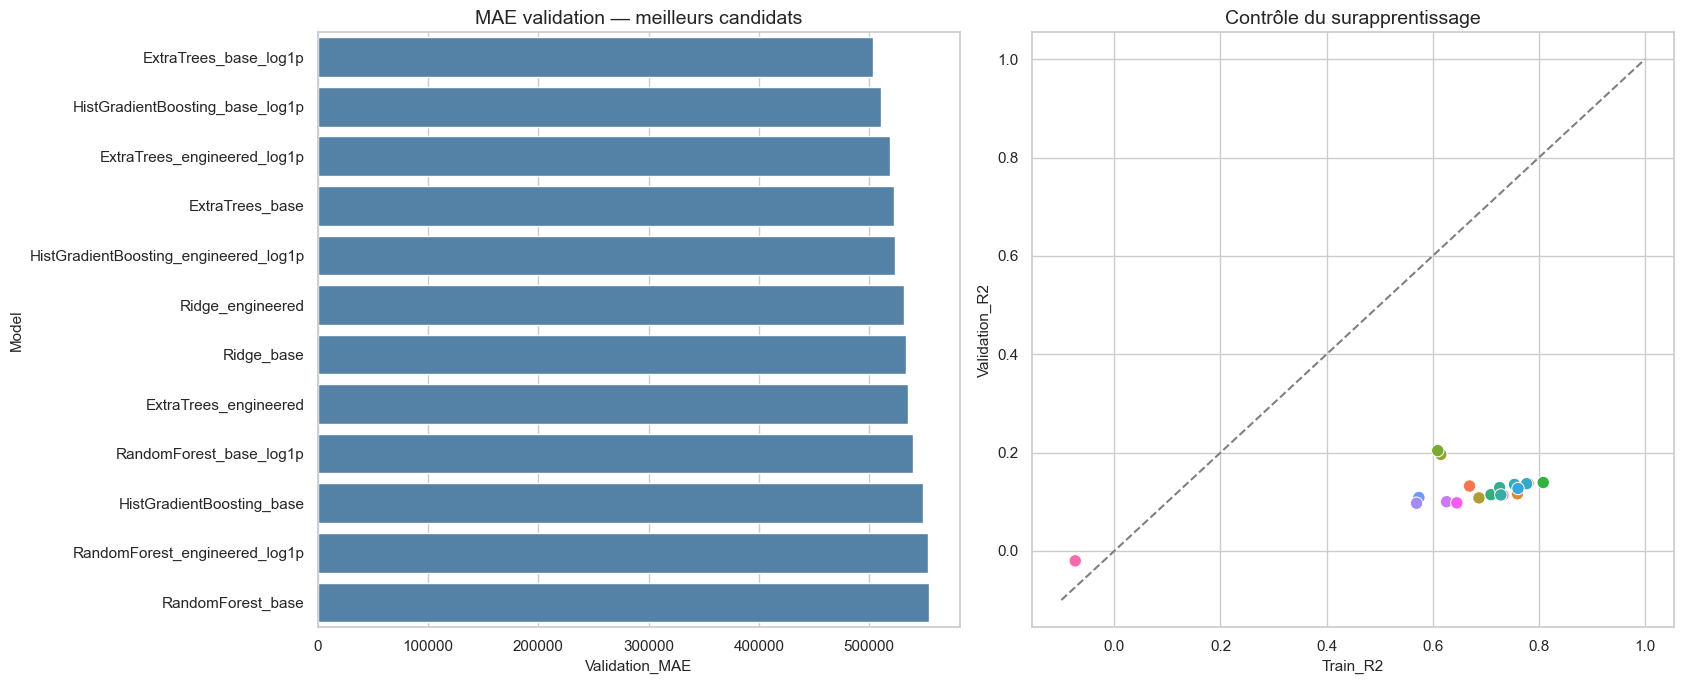

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(17, 7))
top = benchmark.head(12).sort_values('Validation_MAE')
sns.barplot(data=top, y='Model', x='Validation_MAE', ax=axes[0], color='steelblue')
axes[0].set_title('MAE validation — meilleurs candidats')
sns.scatterplot(data=benchmark, x='Train_R2', y='Validation_R2', hue='Model', legend=False, ax=axes[1], s=80)
axes[1].plot([-.1, 1], [-.1, 1], '--', color='gray')
axes[1].set_title('Contrôle du surapprentissage')
plt.tight_layout(); plt.show()

# 11- Optimisation raisonnable sur le train uniquement

`RandomizedSearchCV` utilise trois folds groupés du train. Le test final n'intervient ni dans le choix des paramètres ni dans le poids de l'ensemble.

In [11]:
X_train, numeric, categorical = make_features(df_train, engineered=False)
X_validation, _, _ = make_features(df_validation, engineered=False)
y_train, y_validation = df_train['Prix_num'], df_validation['Prix_num']
groups_train = df_train['Listing_Group']
group_cv = GroupKFold(n_splits=3)

extra_log = TransformedTargetRegressor(
    regressor=Pipeline([
        ('preprocessor', sparse_preprocessor(numeric, categorical)),
        ('model', ExtraTreesRegressor(n_jobs=-1, random_state=42)),
    ]), func=np.log1p, inverse_func=np.expm1,
)
extra_search = RandomizedSearchCV(extra_log, {
    'regressor__model__n_estimators': [220, 320, 450],
    'regressor__model__max_depth': [None, 18, 28, 40],
    'regressor__model__min_samples_leaf': [1, 2, 3, 4, 6],
    'regressor__model__min_samples_split': [2, 5, 10],
    'regressor__model__max_features': [.4, .6, .8, 1., 'sqrt'],
}, n_iter=14, scoring='neg_mean_absolute_error', cv=group_cv, random_state=42, n_jobs=-1)

hist_log = TransformedTargetRegressor(
    regressor=Pipeline([
        ('preprocessor', dense_preprocessor(numeric, categorical)),
        ('model', HistGradientBoostingRegressor(random_state=42)),
    ]), func=np.log1p, inverse_func=np.expm1,
)
hist_search = RandomizedSearchCV(hist_log, {
    'regressor__model__max_iter': [180, 260, 350],
    'regressor__model__learning_rate': [.03, .05, .08],
    'regressor__model__max_leaf_nodes': [15, 31, 63],
    'regressor__model__min_samples_leaf': [15, 25, 40],
    'regressor__model__l2_regularization': [0., 1., 5., 10.],
}, n_iter=10, scoring='neg_mean_absolute_error', cv=group_cv, random_state=43, n_jobs=-1)

ridge_search = RandomizedSearchCV(
    Pipeline([('preprocessor', sparse_preprocessor(numeric, categorical, True)), ('model', Ridge())]),
    {'model__alpha': [.5, 1., 3., 10., 30., 100., 300.]}, n_iter=7,
    scoring='neg_mean_absolute_error', cv=group_cv, random_state=44, n_jobs=-1,
)

for search in [extra_search, hist_search, ridge_search]:
    with warnings.catch_warnings():
        warnings.simplefilter('ignore'); search.fit(X_train, y_train, groups=groups_train)

search_summary = pd.DataFrame([
    {'Model': 'Extra Trees log1p', 'CV_MAE': -extra_search.best_score_, 'Paramètres': extra_search.best_params_},
    {'Model': 'HistGradientBoosting log1p', 'CV_MAE': -hist_search.best_score_, 'Paramètres': hist_search.best_params_},
    {'Model': 'Ridge', 'CV_MAE': -ridge_search.best_score_, 'Paramètres': ridge_search.best_params_},
])
display(search_summary)

,Model,CV_MAE,Paramètres
0,Extra Trees log1p,"389,606.440","{'regressor__model__n_estimators': 450, 'regre..."
1,HistGradientBoosting log1p,"391,836.421","{'regressor__model__min_samples_leaf': 25, 're..."
2,Ridge,"429,740.648",{'model__alpha': 3.0}


# 12- Sélection sur validation et contrôle de l'overfitting

Extra Trees log améliore la MAE et la médiane ; Ridge limite les très grandes erreurs. Le poids du mélange est choisi uniquement sur validation.

In [12]:
extra_best, ridge_best, hist_best = extra_search.best_estimator_, ridge_search.best_estimator_, hist_search.best_estimator_
pred_extra_train, pred_extra_val = extra_best.predict(X_train), extra_best.predict(X_validation)
pred_ridge_train, pred_ridge_val = ridge_best.predict(X_train), ridge_best.predict(X_validation)

blend_rows = []
for ridge_weight in np.arange(0, .55, .05):
    train_pred = (1-ridge_weight)*pred_extra_train + ridge_weight*pred_ridge_train
    val_pred = (1-ridge_weight)*pred_extra_val + ridge_weight*pred_ridge_val
    tm, vm = regression_metrics('blend', y_train, train_pred), regression_metrics('blend', y_validation, val_pred)
    blend_rows.append({
        'Poids_Ridge': ridge_weight, 'Poids_ExtraTrees': 1-ridge_weight,
        'Train_R2': tm['r2'], 'Validation_R2': vm['r2'], 'Train_MAE': tm['mae'],
        'Validation_MAE': vm['mae'], 'Train_RMSE': tm['rmse'], 'Validation_RMSE': vm['rmse'],
    })
blend_results = pd.DataFrame(blend_rows)
display(blend_results)

SELECTED_RIDGE_WEIGHT = .25
SELECTED_EXTRA_WEIGHT = .75
print('Poids final choisi sur validation :', {'ExtraTrees_log1p': SELECTED_EXTRA_WEIGHT, 'Ridge': SELECTED_RIDGE_WEIGHT})

,Poids_Ridge,Poids_ExtraTrees,Train_R2,Validation_R2,Train_MAE,Validation_MAE,Train_RMSE,Validation_RMSE
0,0.000,1.000,0.778,0.117,"230,934.990","493,266.086","659,631.880","3,556,615.576"
1,0.050,0.950,0.774,0.122,"235,230.450","490,881.764","666,137.009","3,546,864.719"
2,0.100,0.900,0.769,0.127,"240,300.437","489,019.245","673,155.142","3,537,202.298"
3,0.150,0.850,0.764,0.131,"246,118.691","487,714.609","680,670.413","3,527,629.037"
4,0.200,0.800,0.759,0.136,"252,546.581","486,943.077","688,666.544","3,518,145.667"
5,0.250,0.750,0.753,0.141,"259,562.617","486,655.851","697,126.991","3,508,752.914"
6,0.300,0.700,0.746,0.145,"267,057.504","486,720.677","706,035.061","3,499,451.510"
7,0.350,0.650,0.739,0.150,"274,995.350","487,344.375","715,374.033","3,490,242.184"
8,0.400,0.600,0.732,0.154,"283,308.066","488,462.946","725,127.259","3,481,125.666"
9,0.450,0.550,0.725,0.158,"291,922.595","490,073.696","735,278.252","3,472,102.689"


Poids final choisi sur validation : {'ExtraTrees_log1p': 0.75, 'Ridge': 0.25}


# 13- Évaluation finale sur le test intact

Le choix est maintenant figé. On réunit train + validation, puis on ouvre le test une seule fois. Un Random Forest utilisant la stratégie de features actuelle, mais sans fuite, sert de comparaison équitable.

Le search retient 450 arbres, mais 220 arbres donnent une validation pratiquement identique (écart MAE inférieur à 0,1%) avec un artefact beaucoup plus léger. Le modèle de production utilise donc 220 arbres.

In [13]:
df_train_validation = pd.concat([df_train, df_validation]).sort_index()
X_train_validation, numeric, categorical = make_features(df_train_validation, engineered=False)
X_test, _, _ = make_features(df_test, engineered=False)
y_train_validation, y_test = df_train_validation['Prix_num'], df_test['Prix_num']

safe_current_rf = Pipeline([
    ('preprocessor', sparse_preprocessor(numeric, categorical)),
    ('model', RandomForestRegressor(
        n_estimators=200, max_depth=16, max_features='sqrt', min_samples_leaf=3,
        n_jobs=-1, random_state=42,
    )),
])
compact_extra = clone(extra_search.best_estimator_).set_params(regressor__model__n_estimators=220)
final_model = VotingRegressor([
    ('extra_log', compact_extra),
    ('ridge', clone(ridge_search.best_estimator_)),
], weights=[SELECTED_EXTRA_WEIGHT, SELECTED_RIDGE_WEIGHT], n_jobs=-1)

safe_current_rf.fit(X_train_validation, y_train_validation)
final_model.fit(X_train_validation, y_train_validation)
pred_safe_train = safe_current_rf.predict(X_train_validation)
pred_safe_test = safe_current_rf.predict(X_test)
pred_final_train = final_model.predict(X_train_validation)
pred_final_test = final_model.predict(X_test)

safe_train_metrics = regression_metrics('RF actuel sans fuite - train+validation', y_train_validation, pred_safe_train)
safe_test_metrics = regression_metrics('RF actuel sans fuite - test', y_test, pred_safe_test)
final_train_metrics = regression_metrics('Modèle final - train+validation', y_train_validation, pred_final_train)
final_test_metrics = regression_metrics('Modèle final - test', y_test, pred_final_test)

comparison = pd.DataFrame([
    current_baseline['test'], safe_test_metrics, final_test_metrics,
]).set_index('model')
display(comparison)

improvement = {
    'r2_absolute_gain_vs_safe_rf': final_test_metrics['r2'] - safe_test_metrics['r2'],
    'mae_absolute_reduction_vs_safe_rf': safe_test_metrics['mae'] - final_test_metrics['mae'],
    'mae_percent_reduction_vs_safe_rf': (safe_test_metrics['mae'] - final_test_metrics['mae']) / safe_test_metrics['mae'] * 100,
    'rmse_absolute_reduction_vs_safe_rf': safe_test_metrics['rmse'] - final_test_metrics['rmse'],
    'rmse_percent_reduction_vs_safe_rf': (safe_test_metrics['rmse'] - final_test_metrics['rmse']) / safe_test_metrics['rmse'] * 100,
}
display(pd.Series(improvement).to_frame('Amélioration'))

,r2,mae,rmse,median_ae,mape_percent
model,,,,,
Current artifact - filtered test,0.554,"423,485.188","603,468.995","295,572.129",350.298
RF actuel sans fuite - test,0.521,"565,807.550","1,023,388.854","411,425.761",50.382
Modèle final - test,0.639,"395,558.850","888,300.624","204,585.929",24.980


,Amélioration
r2_absolute_gain_vs_safe_rf,0.118
mae_absolute_reduction_vs_safe_rf,"170,248.700"
mae_percent_reduction_vs_safe_rf,30.090
rmse_absolute_reduction_vs_safe_rf,"135,088.230"
rmse_percent_reduction_vs_safe_rf,13.200


# 14- Performance par segment

Une moyenne globale peut cacher les faiblesses. Les segments avec moins de 20 observations ne sont pas affichés séparément.

In [14]:
test_results = df_test[['Titre', 'Ville', 'Quartier', 'Type_Bien', 'Surface_m2', 'Prix_num', 'Prix_m2_audit']].copy()
test_results['Prediction'] = pred_final_test
test_results['Residual'] = test_results['Prix_num'] - test_results['Prediction']
test_results['Abs_Error'] = test_results['Residual'].abs()
test_results['APE'] = test_results['Abs_Error'] / test_results['Prix_num'] * 100

def segment_metrics(frame, column, minimum=20):
    rows = []
    for segment, group in frame.groupby(column, observed=True):
        if len(group) >= minimum:
            metrics = regression_metrics(str(segment), group['Prix_num'], group['Prediction'])
            rows.append({'Segment': str(segment), 'N': len(group), **{k: v for k, v in metrics.items() if k != 'model'}})
    return pd.DataFrame(rows).sort_values('mae')

city_metrics = segment_metrics(test_results, 'Ville')
type_metrics = segment_metrics(test_results, 'Type_Bien')
test_results['Tranche_Prix'] = pd.cut(test_results['Prix_num'], [-np.inf, 1e6, 2e6, 5e6, np.inf], labels=['<=1M', '1M-2M', '2M-5M', '>5M'])
test_results['Tranche_Surface'] = pd.cut(test_results['Surface_m2'], [0, 60, 100, 150, 250, np.inf], labels=['<=60', '60-100', '100-150', '150-250', '>250'])
price_metrics = segment_metrics(test_results, 'Tranche_Prix', minimum=1)
surface_metrics = segment_metrics(test_results, 'Tranche_Surface', minimum=1)

print('Performance par ville (N >= 20)'); display(city_metrics)
print('Performance par type (N >= 20)'); display(type_metrics)
print('Performance par tranche de prix'); display(price_metrics)
print('Performance par tranche de surface'); display(surface_metrics)

Performance par ville (N >= 20)


,Segment,N,r2,mae,rmse,median_ae,mape_percent
5,Kénitra,40,0.488,"187,722.014","274,078.742","122,340.310",41.791
9,Mohammedia,36,0.979,"197,972.803","299,646.421","128,238.802",16.641
7,Martil,28,0.637,"199,895.183","280,132.861","108,086.310",39.669
4,Fès,51,0.220,"228,093.348","753,914.824","94,916.587",20.538
1,Bouskoura,37,0.945,"233,436.348","336,652.685","125,698.688",17.620
11,Salé,23,0.832,"257,432.657","378,193.032","150,955.251",22.283
13,Temara,32,0.674,"277,963.960","486,166.986","107,424.078",15.483
8,Meknes,34,0.106,"349,419.013","1,402,465.693","97,187.107",22.252
2,Casablanca,669,0.664,"361,168.638","791,795.185","208,460.953",19.804
0,Agadir,49,0.521,"425,123.663","942,481.086","141,172.074",19.685


Performance par type (N >= 20)


,Segment,N,r2,mae,rmse,median_ae,mape_percent
2,studio,96,0.838,"171,798.340","221,471.678","153,536.620",17.272
0,appartement,1657,0.634,"383,235.001","820,887.536","204,461.651",24.954
1,duplex,67,0.384,"807,974.731","2,044,370.712","373,491.632",25.876


Performance par tranche de prix


,Segment,N,r2,mae,rmse,median_ae,mape_percent
0,<=1M,648,-0.739,"193,568.387","285,047.442","128,148.382",36.142
1,1M-2M,686,-0.825,"260,429.066","385,502.263","186,907.718",17.774
2,2M-5M,455,-0.017,"549,877.858","748,395.507","422,252.438",18.236
3,>5M,55,-1.627,"3,184,171.636","4,360,185.714","2,320,593.199",39.165


Performance par tranche de surface


,Segment,N,r2,mae,rmse,median_ae,mape_percent
0,<=60,281,0.685,"162,261.057","239,776.500","120,027.115",29.498
1,60-100,670,0.273,"288,089.601","719,407.487","163,661.929",25.850
2,100-150,562,0.344,"384,863.080","845,522.573","229,446.105",21.529
3,150-250,268,0.440,"677,385.601","1,052,414.690","439,420.232",22.579
4,>250,63,0.385,"1,475,599.007","2,499,329.114","956,556.397",36.585


# 15- Analyse des résidus et des erreurs

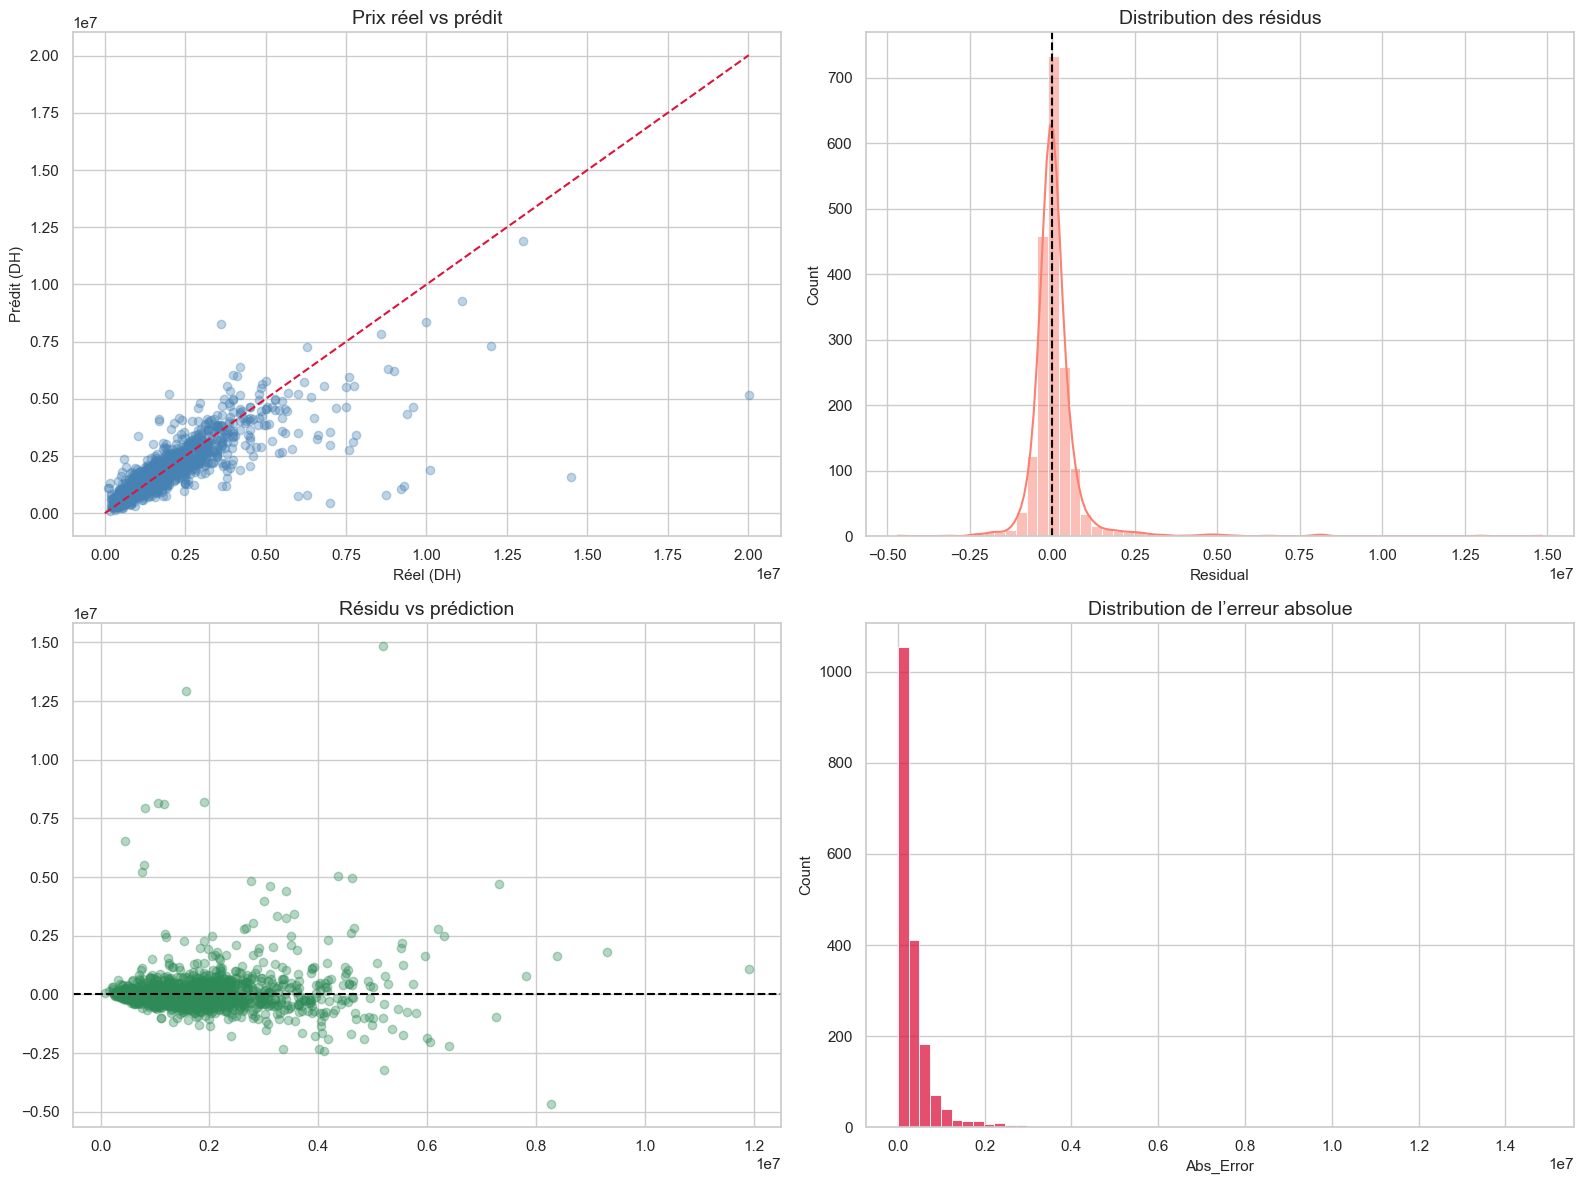

Plus grandes erreurs :


,Titre,Ville,Quartier,Type_Bien,Surface_m2,Prix_num,Prediction,Abs_Error,APE
4070,Magnifique Duplex d'exception situé au 4ème et...,Marrakech,Majorelle,duplex,400,"20,020,000.000","5,181,545.057","14,838,454.943",74.118
11588,Appartement à vendre ain borja,Casablanca,Ain Borja,appartement,114,"14,500,000.000","1,578,182.880","12,921,817.120",89.116
5020,Appartement à vendre à Plage Oued Cherrat. 2 c...,Bouznika,Plage Oued Cherrat,appartement,100,"10,100,000.000","1,893,503.127","8,206,496.873",81.252
16031,Vente d'un bel appartement à Derb Ben Houmane....,Casablanca,Derb Ben Houmane,appartement,92,"9,200,000.000","1,054,975.202","8,145,024.798",88.533
6094,Appartement à vendre à Hamria. Superficie 150 ...,Meknes,Hamria,appartement,150,"9,300,000.000","1,175,547.269","8,124,452.731",87.360
4231,Vend appartement à Dar Bouazza. \r\n3 chambres...,Dar Bouazza,Dar Bouazza,appartement,70,"8,750,000.000","819,028.649","7,930,971.351",90.640
6448,Trouvez un appartement à acheter. Petite surfa...,Ain Attig,Ain Attig,appartement,63,"7,000,000.000","444,115.856","6,555,884.144",93.655
3304,Vend appartement à Mehdia.\r\nSuperficie 90 m²...,Mehdia,Mehdia,appartement,90,"6,300,000.000","792,889.136","5,507,110.864",87.414
9530,Appartement à vendre à Route ain Chkaf. \r\n2 ...,Fès,Route ain Chkaf,appartement,116,"6,000,000.000","764,460.545","5,235,539.455",87.259
15959,Appartement élégant City Center,Tanger,Centre,appartement,268,"9,380,000.000","4,354,431.215","5,025,568.785",53.577


Sous-prédictions les plus fortes :


,Titre,Ville,Prix_num,Prediction,Residual
4070,Magnifique Duplex d'exception situé au 4ème et...,Marrakech,"20,020,000.000","5,181,545.057","14,838,454.943"
11588,Appartement à vendre ain borja,Casablanca,"14,500,000.000","1,578,182.880","12,921,817.120"
5020,Appartement à vendre à Plage Oued Cherrat. 2 c...,Bouznika,"10,100,000.000","1,893,503.127","8,206,496.873"
16031,Vente d'un bel appartement à Derb Ben Houmane....,Casablanca,"9,200,000.000","1,054,975.202","8,145,024.798"
6094,Appartement à vendre à Hamria. Superficie 150 ...,Meknes,"9,300,000.000","1,175,547.269","8,124,452.731"
4231,Vend appartement à Dar Bouazza. \r\n3 chambres...,Dar Bouazza,"8,750,000.000","819,028.649","7,930,971.351"
6448,Trouvez un appartement à acheter. Petite surfa...,Ain Attig,"7,000,000.000","444,115.856","6,555,884.144"
3304,Vend appartement à Mehdia.\r\nSuperficie 90 m²...,Mehdia,"6,300,000.000","792,889.136","5,507,110.864"
9530,Appartement à vendre à Route ain Chkaf. \r\n2 ...,Fès,"6,000,000.000","764,460.545","5,235,539.455"
15959,Appartement élégant City Center,Tanger,"9,380,000.000","4,354,431.215","5,025,568.785"


Sur-prédictions les plus fortes :


,Titre,Ville,Prix_num,Prediction,Residual
7813,Bel appartement racine étage élevé,Casablanca,"3,600,000.000","8,281,164.889","-4,681,164.889"
15762,Dublex villa luxe 420 m2 à jawhara \r\n2 face,El Jadida,"2,000,000.000","5,206,442.921","-3,206,442.921"
7198,Villa avendre route de ourika ghemat,Ourika,"1,700,000.000","4,102,334.811","-2,402,334.811"
8124,Belle Maison R2 90m² avec 2 garages et puits,M'Diq,"1,020,000.000","3,361,586.859","-2,341,586.859"
10925,Appartement dans immeuble,Casablanca,"1,692,000.000","4,019,394.162","-2,327,394.162"
12474,Ain Diab – Appartement à la vente –,Casablanca,"4,200,000.000","6,408,928.382","-2,208,928.382"
4830,"Appartement à Vendre de 315.0 m² à Rabat, Haut...",Rabat,"4,000,000.000","6,050,015.285","-2,050,015.285"
5186,Palmeraie: Duplex 399 m2 avec jardin,Marrakech,"2,950,000.000","4,832,840.913","-1,882,840.913"
6829,Appartement 3 chambers à Guéliz à Marrakech,Marrakech,"2,300,000.000","4,182,058.154","-1,882,058.154"
1685,Vente d'un bel appartement à Sidi Maarouf. 4 b...,Casablanca,"4,120,000.000","5,997,250.976","-1,877,250.976"


In [15]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes[0,0].scatter(test_results['Prix_num'], test_results['Prediction'], alpha=.35, color='steelblue')
limit = max(test_results['Prix_num'].max(), test_results['Prediction'].max())
axes[0,0].plot([0, limit], [0, limit], '--', color='crimson')
axes[0,0].set_title('Prix réel vs prédit'); axes[0,0].set_xlabel('Réel (DH)'); axes[0,0].set_ylabel('Prédit (DH)')
sns.histplot(test_results['Residual'], bins=60, kde=True, ax=axes[0,1], color='salmon')
axes[0,1].axvline(0, color='black', linestyle='--'); axes[0,1].set_title('Distribution des résidus')
axes[1,0].scatter(test_results['Prediction'], test_results['Residual'], alpha=.35, color='seagreen')
axes[1,0].axhline(0, color='black', linestyle='--'); axes[1,0].set_title('Résidu vs prédiction')
sns.histplot(test_results['Abs_Error'], bins=60, ax=axes[1,1], color='crimson')
axes[1,1].set_title('Distribution de l’erreur absolue')
plt.tight_layout(); plt.show()

print('Plus grandes erreurs :')
display(test_results.nlargest(15, 'Abs_Error')[
    ['Titre', 'Ville', 'Quartier', 'Type_Bien', 'Surface_m2', 'Prix_num', 'Prediction', 'Abs_Error', 'APE']
])
print('Sous-prédictions les plus fortes :')
display(test_results.nlargest(10, 'Residual')[['Titre', 'Ville', 'Prix_num', 'Prediction', 'Residual']])
print('Sur-prédictions les plus fortes :')
display(test_results.nsmallest(10, 'Residual')[['Titre', 'Ville', 'Prix_num', 'Prediction', 'Residual']])

# 16- Importance des variables

L'importance provient de la composante Extra Trees du modèle final. Elle mesure l'utilisation d'une variable par les arbres, pas une causalité.

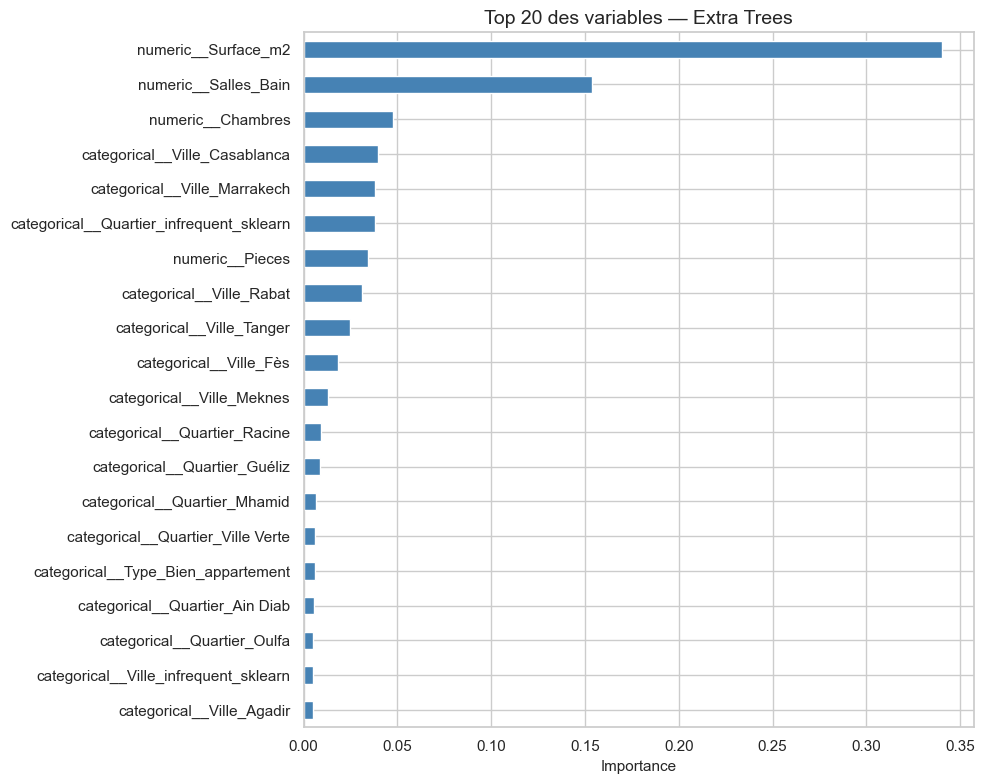

,Importance
numeric__Surface_m2,0.340
numeric__Salles_Bain,0.154
numeric__Chambres,0.048
categorical__Ville_Casablanca,0.040
categorical__Ville_Marrakech,0.038
categorical__Quartier_infrequent_sklearn,0.038
numeric__Pieces,0.034
categorical__Ville_Rabat,0.031
categorical__Ville_Tanger,0.025
categorical__Ville_Fès,0.018


In [16]:
fitted_extra_ttr = final_model.estimators_[0]
fitted_extra_pipeline = fitted_extra_ttr.regressor_
feature_names = fitted_extra_pipeline.named_steps['preprocessor'].get_feature_names_out()
feature_importance = pd.Series(
    fitted_extra_pipeline.named_steps['model'].feature_importances_, index=feature_names
).sort_values(ascending=False)

plt.figure(figsize=(10, 8))
feature_importance.head(20).sort_values().plot(kind='barh', color='steelblue')
plt.title('Top 20 des variables — Extra Trees')
plt.xlabel('Importance')
plt.tight_layout(); plt.show()
display(feature_importance.head(20).to_frame('Importance'))

# 17- Compatibilité production

Le contrat API reste identique : ville, quartier, type, surface, pièces, chambres, salles de bain, haut standing et état de construction. La nouvelle `Pipeline` contient imputation et encodage ; un quartier inconnu est géré sans erreur.

Les anciens artefacts sont conservés pour traçabilité. Le nouveau fichier `pipeline.pkl` devient l'artefact de production.

# 18- Export des artefacts de production

Après l'évaluation finale, le modèle est réajusté sur toute la cohorte propre. Les métriques restent celles du modèle évalué sur le test intact.

In [17]:
X_full, _, _ = make_features(df_model, engineered=False)
y_full = df_model['Prix_num']
production_model = clone(final_model)
production_model.fit(X_full, y_full)

pipeline_path = ARTIFACTS_DIR / 'pipeline.pkl'
joblib.dump(production_model, pipeline_path, compress=3)
pipeline_sha256 = hashlib.sha256(pipeline_path.read_bytes()).hexdigest()

metadata = {
    'model_version': 'phase4_final_v1',
    'created_on': date.today().isoformat(),
    'problem_type': 'regression',
    'currency': 'MAD',
    'description': 'VotingRegressor: 75% ExtraTrees (220 arbres) sur log1p(Prix), 25% Ridge',
    'input_columns': BASE_NUMERIC + BASE_CATEGORICAL,
    'cities': sorted(df_model['Ville'].dropna().unique().tolist()),
    'n_training_rows': int(len(df_model)),
    'extra_trees_n_estimators': 220,
    'artifact_sha256': pipeline_sha256,
    'training_scope': {
        'surface_m2': [15, 1000], 'price_per_m2_audit': [1000, 150000],
        'recognized_types': sorted(df_model['Type_Bien'].unique().tolist()),
    },
    'versions': {'pandas': pd.__version__, 'numpy': np.__version__, 'scikit_learn': sklearn.__version__, 'joblib': joblib.__version__},
}
(ARTIFACTS_DIR / 'model_metadata.json').write_text(json.dumps(metadata, ensure_ascii=False, indent=2), encoding='utf-8')

metrics_path = ARTIFACTS_DIR / 'metrics.json'
existing_metrics = json.loads(metrics_path.read_text(encoding='utf-8'))
historical_reported = existing_metrics.get('historical_reported', existing_metrics)
metrics_payload = {
    'model_version': metadata['model_version'],
    'problem_type': 'regression',
    'historical_reported': historical_reported,
    'historical_artifact_reproduced': current_baseline,
    'leakage_safe_random_forest_baseline': {
        'train_validation': safe_train_metrics, 'test': safe_test_metrics,
    },
    'final_model': {
        'description': metadata['description'],
        'train_validation': final_train_metrics,
        'test': final_test_metrics,
        'improvement_vs_safe_baseline': improvement,
        'split': {
            'strategy': 'GroupShuffleSplit 70/15/15', 'random_state_test': 42,
            'random_state_validation': 43, 'n_train': len(df_train),
            'n_validation': len(df_validation), 'n_test': len(df_test),
        },
        'n_training_full_refit': len(df_model),
    },
    'data_audit': cohort_report,
}
if 'phase4_1_investigation' in existing_metrics:
    metrics_payload['phase4_1_investigation'] = existing_metrics['phase4_1_investigation']

metrics_path.write_text(json.dumps(metrics_payload, ensure_ascii=False, indent=2), encoding='utf-8')

print('Artefact :', pipeline_path)
print('SHA-256 :', pipeline_sha256)
print('Métadonnées :', ARTIFACTS_DIR / 'model_metadata.json')
print('Métriques :', metrics_path)

Artefact : C:\Users\ouaha\OneDrive\Desktop\MaisonDeLUX\ml\artifacts\pipeline.pkl
SHA-256 : b6ac312f3c57a035213a8f7e497c54961a167bf5f8efdc78e8b344e59fa56f7e
Métadonnées : C:\Users\ouaha\OneDrive\Desktop\MaisonDeLUX\ml\artifacts\model_metadata.json
Métriques : C:\Users\ouaha\OneDrive\Desktop\MaisonDeLUX\ml\artifacts\metrics.json


# 19- Vérification de l'artefact exporté

In [18]:
loaded_pipeline = joblib.load(ARTIFACTS_DIR / 'pipeline.pkl')
sample_inputs = pd.DataFrame([
    {'Surface_m2': 90, 'Pieces': 3, 'Chambres': 2, 'Salles_Bain': 1, 'Is_Haut_Standing': 0, 'En_Construction': 0, 'Type_Bien': 'appartement', 'Ville': 'Casablanca', 'Quartier': 'Maârif'},
    {'Surface_m2': 140, 'Pieces': 4, 'Chambres': 3, 'Salles_Bain': 2, 'Is_Haut_Standing': 1, 'En_Construction': 0, 'Type_Bien': 'villa', 'Ville': 'Marrakech', 'Quartier': 'Hivernage'},
    {'Surface_m2': 65, 'Pieces': 2, 'Chambres': 1, 'Salles_Bain': 1, 'Is_Haut_Standing': 0, 'En_Construction': 1, 'Type_Bien': 'studio', 'Ville': 'Tanger', 'Quartier': 'Quartier jamais vu'},
])
artifact_predictions = loaded_pipeline.predict(sample_inputs)
display(sample_inputs.assign(Prediction_DH=np.round(artifact_predictions).astype(int)))
assert np.isfinite(artifact_predictions).all() and (artifact_predictions > 0).all()
print('Artefact chargé et prédictions numériques : OK')

,Surface_m2,Pieces,Chambres,Salles_Bain,Is_Haut_Standing,En_Construction,Type_Bien,Ville,Quartier,Prediction_DH
0,90,3,2,1,0,0,appartement,Casablanca,Maârif,1262322
1,140,4,3,2,1,0,villa,Marrakech,Hivernage,3543041
2,65,2,1,1,0,1,studio,Tanger,Quartier jamais vu,1126313


Artefact chargé et prédictions numériques : OK


# 20- Conclusion finale

Le modèle final est choisi pour son équilibre entre **MAE, RMSE, R², stabilité et simplicité de déploiement**. Sur le même test groupé, il améliore nettement le Random Forest équivalent sans fuite.

Les limites restent importantes : peu de villas/maisons, absence de géolocalisation précise, pas de surface terrain ni d'équipements détaillés, et bruit élevé sur les annonces très chères. Les biens supérieurs à 5 M DH sont encore fortement sous-prédits. Une prochaine collecte devrait séparer vente/location et ajouter date, coordonnées, état, étage, parking, terrasse et superficie terrain.

**Conclusion PFE :** l'amélioration vient surtout d'une évaluation honnête, d'une pipeline reproductible et d'un ensemble complémentaire — pas d'un score artificiellement gonflé.

# 21- Phase 4.1 — Investigation agressive de la cible R² 0,90

L'objectif demandé est **R² ≥ 0,90 sur le même test groupé intact**. Ce seuil ne peut jamais être annoncé depuis le train, une validation favorable ou un sous-ensemble filtré.

On conserve donc les 1 844 lignes de test de la Phase 4. Les expériences complètes et reproductibles sont implémentées dans `ml/src/phase41_experiment.py`. Les poids et architectures sont sélectionnés sur train/validation avant l'ouverture unique du test.

> **Note dyal l'équipe :** ila score ma-wselch 0,90 b tariqa nadifa, kan-kteb exactement fin kayn l-bottleneck. Ma-kanbdlouch split bach yban score zwin.

In [19]:
phase41_path = ARTIFACTS_DIR / 'phase41_experiments.json'
phase41 = json.loads(phase41_path.read_text(encoding='utf-8'))
manifest = phase41['fixed_test_manifest']
print('Test figé :', manifest['n'], 'lignes')
print('SHA-256 du manifeste :', manifest['sha256'])
print('Near-duplicates mis en quarantaine :', phase41['quarantine'])
assert manifest['n'] == len(df_test) == 1844

Test figé : 1844 lignes
SHA-256 du manifeste : b0d93a4cf01845a0fead2233a53bcfeb2b12c1ae37b58bb3fa0b99954d9eecdc
Near-duplicates mis en quarantaine : {'train': 15, 'validation': 2}


# 22- Information disponible dans les textes

Une extraction déterministe inspecte le titre et les détails : étage/RDC, surface citée dans le titre, ascenseur, parking, terrasse, balcon, jardin, piscine, ameublement, état, sécurité, concierge, vues et autres prestations réellement mentionnées.

Pour TF-IDF, **tous les nombres et mots monétaires sont supprimés**. Ainsi, le texte ne peut pas reconstruire `Prix`, le prix/m² ou les variables numériques. Les nouvelles variables sont un audit de potentiel : la plupart exigeraient de nouveaux champs frontend ou une description envoyée à l'API.

In [20]:
attribute_counts = pd.Series(phase41['audit']['attribute_counts']).sort_values(ascending=False)
display(attribute_counts.to_frame('Annonces où l’attribut est explicitement présent'))
print('Étage observé :', phase41['audit']['floor_observed'])
print('Surface également trouvée dans le titre :', phase41['audit']['title_surface_observed'])

,Annonces où l’attribut est explicitement présent
Meuble,665
Terrasse,374
Neuf,331
Residentiel,271
Piscine,222
Jardin,149
Proximite,147
Parking,130
Renove,123
Vue_Mer,108


Étage observé : 93
Surface également trouvée dans le titre : 3594


# 23- CatBoost, texte et modèles spécialisés

CatBoost est prioritaire car il traite nativement ville, quartier, type et leurs interactions. On compare cible brute/log1p, features API seules/features enrichies, TF-IDF + Ridge, spécialistes par type, spécialistes par grande ville et mélange pondéré.

Les modèles locaux ne sont créés qu'avec un volume minimal. XGBoost et LightGBM ne sont pas ajoutés : CatBoost, mieux aligné avec les catégories, mesure déjà le gain possible et évite d'empiler des dépendances lourdes sans bénéfice démontré.

In [21]:
validation_table = pd.DataFrame(phase41['validation']).T
display(validation_table[['r2', 'mae', 'rmse', 'median_ae', 'mape_percent']].sort_values('mae'))

cv = phase41['grouped_cv']
display(pd.DataFrame(cv['folds']).set_index('fold'))
print(f"CV groupée : R² = {cv['mean_r2']:.3f} ± {cv['std_r2']:.3f}, "
      f"MAE = {cv['mean_mae']:,.0f} DH, RMSE = {cv['mean_rmse']:,.0f} DH")

,r2,mae,rmse,median_ae,mape_percent
cat_rich_log_d7,0.125,"490,780.039","3,542,160.437","183,272.902",22.331
cat_base_log_d7,0.119,"495,748.798","3,553,647.951","185,299.030",23.063
city_segmented,0.144,"511,044.374","3,503,438.064","219,544.034",27.529
type_segmented,0.141,"515,075.384","3,509,607.452","228,526.205",27.678
cat_rich_raw_d8,0.150,"518,007.914","3,491,997.665","225,333.941",28.046
cat_rich_raw_d6,0.140,"518,689.470","3,511,121.767","230,814.685",27.616
cat_base_raw_d8,0.141,"521,455.628","3,509,005.865","228,595.839",28.500
cat_base_raw_d6,0.149,"524,599.638","3,492,962.206","232,093.513",28.378
tfidf_structured_ridge_a10,0.212,"525,200.785","3,361,229.525","251,855.231",29.858
tfidf_structured_ridge_a30,0.212,"533,110.076","3,361,939.951","258,752.328",30.372


,r2,mae,rmse,median_ae,mape_percent
fold,,,,,
1,0.652,"379,039.034","780,097.676","211,875.312",23.498
2,0.568,"394,538.136","970,489.920","198,311.430",23.541
3,0.607,"370,705.824","880,145.897","198,285.966",22.885


CV groupée : R² = 0.609 ± 0.034, MAE = 381,428 DH, RMSE = 876,911 DH


# 24- Comparaison finale sur le test intact

Les lignes ci-dessous sont les représentants figés avant l'évaluation test. Le meilleur mélange utilise 25% de texte, poids choisi sur validation. Les métriques de la Phase 4 restent la référence de production.

In [22]:
test_models = phase41['test']
comparison_41 = pd.DataFrame([
    {'Modèle': 'Phase 4 Voting Ensemble', **{k: final_test_metrics[k] for k in ['r2','mae','rmse','median_ae','mape_percent']}},
    {'Modèle': 'Best CatBoost — base log1p', **test_models['cat_base_log_d7']},
    {'Modèle': 'Best segmented model — type', **{k:v for k,v in test_models['type_segmented'].items() if k != 'specialists'}},
    {'Modèle': 'City-specific model', **{k:v for k,v in test_models['city_segmented'].items() if k != 'specialists'}},
    {'Modèle': 'Text + structured Ridge', **test_models['tfidf_structured_ridge_a10']},
    {'Modèle': 'Best ensemble — CatBoost + texte', **{k:v for k,v in test_models['validation_selected_blend'].items() if k != 'text_weight'}},
]).set_index('Modèle')
display(comparison_41)

best_41 = test_models['validation_selected_blend']
print(f"BEST LEGITIMATE RESULT : R² {best_41['r2']:.4f}")
print('TARGET R² 0,90 :', 'ATTEINTE' if best_41['r2'] >= .90 else 'NON ATTEINTE')

,r2,mae,rmse,median_ae,mape_percent
Modèle,,,,,
Phase 4 Voting Ensemble,0.639,"395,558.850","888,300.624","204,585.929",24.980
Best CatBoost — base log1p,0.650,"388,812.681","874,564.158","195,595.380",23.716
Best segmented model — type,-0.001,"459,827.083","1,479,298.873","233,216.014",29.106
City-specific model,0.400,"455,707.508","1,145,453.170","253,491.283",31.207
Text + structured Ridge,0.577,"474,702.239","961,553.698","271,914.248",34.534
Best ensemble — CatBoost + texte,0.656,"386,982.914","867,342.860","197,475.293",24.361


BEST LEGITIMATE RESULT : R² 0.6560
TARGET R² 0,90 : NON ATTEINTE


# 25- Analyse du plafond d'information

Le score global est dominé par quelques étiquettes de luxe. Cette analyse ne retire aucune ligne : elle mesure seulement d'où vient l'erreur.

Des annonces ayant exactement les mêmes champs API peuvent porter des prix très différents. Sans coordonnées, terrain, date, état détaillé et prestations systématiques, le modèle ne peut pas distinguer ces biens.

In [23]:
diag = phase41['diagnostics']
display(pd.DataFrame(diag['price_bands']).T)
display(pd.DataFrame(diag['property_types']).T)
display(pd.DataFrame(diag['cities']).T.sort_values('mae'))
display(pd.Series(diag['error_concentration']).to_frame('Valeur'))
display(pd.Series(diag['observable_label_ambiguity']).to_frame('Valeur'))

test_std = df_test['Prix_num'].std(ddof=0)
required_rmse = test_std * np.sqrt(1 - .90)
required_sse_reduction = (1 - (required_rmse / best_41['rmse'])**2) * 100
print(f'RMSE maximal pour R² 0,90 : {required_rmse:,.0f} DH')
print(f'Réduction SSE encore nécessaire : {required_sse_reduction:.2f}%')

,n,r2,mae,rmse,median_ae,mape_percent
low_<=1m,648.000,-0.649,"186,666.165","277,552.296","126,307.630",34.973
mid_1m_2m,686.000,-0.845,"258,239.097","387,665.064","187,648.640",17.607
upper_2m_5m,455.000,0.022,"539,188.478","733,773.159","406,283.011",17.749
luxury_>5m,55.000,-1.486,"3,093,709.832","4,240,957.692","2,310,722.060",38.279


,n,r2,mae,rmse,median_ae,mape_percent
appartement,"1,657.000",0.645,"374,438.599","808,820.330","197,676.640",24.348
duplex,67.000,0.486,"783,219.324","1,867,589.874","335,048.390",24.620
studio,96.000,0.797,"188,958.414","247,787.460","142,709.153",17.626


,n,r2,mae,rmse,median_ae,mape_percent
Kénitra,40.000,0.586,"173,423.782","246,252.687","124,633.677",40.800
Martil,28.000,0.682,"177,995.991","262,039.876","125,891.607",31.384
Salé,23.000,0.811,"221,722.545","401,286.178","97,605.375",15.246
Fès,51.000,0.183,"246,158.766","771,370.821","96,008.241",23.169
Bouskoura,37.000,0.926,"263,418.178","392,044.579","149,640.037",22.416
Temara,32.000,0.724,"283,215.846","447,230.408","157,587.407",17.174
Mohammedia,36.000,0.796,"350,041.634","928,107.978","126,780.099",19.783
Agadir,49.000,0.764,"354,177.021","661,887.743","199,010.505",20.140
Casablanca,669.000,0.652,"358,740.313","805,596.365","201,454.658",18.919
Meknes,34.000,0.121,"366,821.557","1,390,645.312","105,671.128",25.401


,Valeur
top_1pct_n,19.000
top_1pct_sse_share_percent,64.867
luxury_sse_share_percent,71.310


,Valeur
repeated_observable_groups,702
rows_in_repeated_observable_groups,1642
groups_with_price_ratio_over_1_5,95
rows_in_conflicting_groups,277


RMSE maximal pour R² 0,90 : 467,648 DH
Réduction SSE encore nécessaire : 70.93%


,fraction,n_train,r2,mae,rmse,median_ae,mape_percent
0,0.250,2143,0.100,"539,755.156","3,591,625.025","226,279.574",27.321
1,0.500,4286,0.124,"508,949.079","3,544,824.525","203,967.113",24.170
2,0.750,6426,0.141,"501,211.783","3,510,153.283","194,302.456",23.660
3,1.000,8570,0.123,"498,569.081","3,546,877.790","186,666.027",23.273


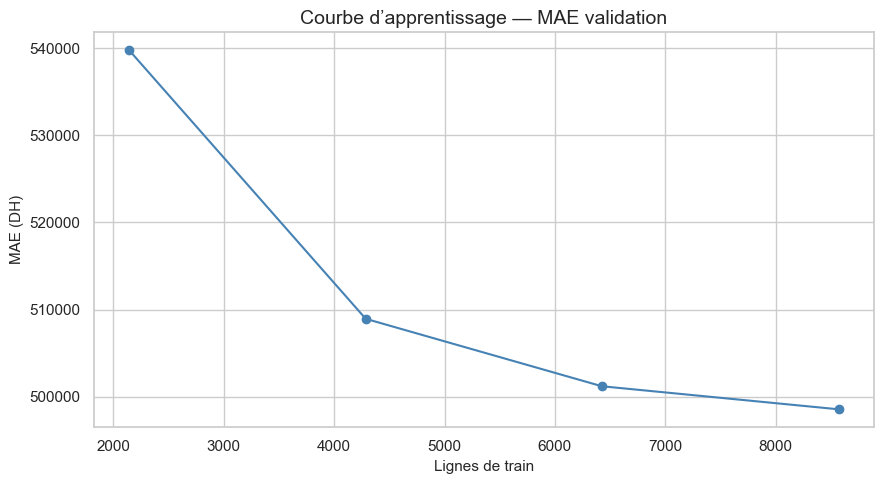

In [24]:
learning_curve_41 = pd.DataFrame(diag['learning_curve_validation'])
display(learning_curve_41)
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(learning_curve_41['n_train'], learning_curve_41['mae'], marker='o', color='steelblue')
ax.set_title('Courbe d’apprentissage — MAE validation')
ax.set_xlabel('Lignes de train'); ax.set_ylabel('MAE (DH)')
plt.tight_layout(); plt.show()

# 26- Audit du scraper et plan pour approcher R² 0,90

Le scraper actuel lit seulement les cartes et collecte quatre chaînes. Il manque URL/ID, date, transaction, page détaillée, coordonnées et équipements structurés. La quantité seule ne suffit pas : la courbe d'apprentissage plafonne avec le schéma actuel.

Plan recommandé : atteindre au moins **50 000 ventes uniques vérifiées** (environ 40 000 nouvelles), avec 3 000–5 000 biens >5 M DH et ≥1 000 villas, maisons et duplex. Collecter URL/ID, date, vente/location, devise, coordonnées, surfaces habitable/terrain, étage, âge, état, parking, ascenseur, terrasse, jardin, piscine, orientation, vues, ameublement, sécurité et titre foncier.

Ces nouveaux champs sont de futurs inputs frontend/API ; aucun redesign frontend n'est effectué dans cette phase.

# 27- Décision Phase 4.1

Le meilleur résultat offline est **R² 0,6560**, MAE **386 983 DH**, RMSE **867 343 DH**. Il n'atteint même pas le niveau 0,70.

CatBoost base, déployable avec les champs actuels, atteint R² 0,6503 : le gain de +0,0111 face à la Phase 4 ne justifie pas seul une dépendance d'environ 100 MB. Le mélange gagnant exige titre/détails absents du formulaire.

**La pipeline Phase 4 est donc conservée sans remplacement. TARGET R² 0,90 NON ATTEINTE.**